<a href="https://colab.research.google.com/github/AbhiD200428/cuddly-spork/blob/master/AIMLL_Ass_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 5
Linear Regression

Required Libraries

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Loading Data

In [60]:
df = pd.read_csv('/salary_data - salary_data.csv')

### Understanding Dataset

In [61]:
df

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [63]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [64]:
df_top = df.head()
df.bottom = df.tail()
print(df_top)
print(df.bottom)

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
    YearsExperience  Salary
25              9.0  105582
26              9.5  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872


<ipython-input-64-c6d7909cc3fd>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.bottom = df.tail()


Insight: Dataset has 2 features (YearsExperience and Salary), 30 entries of which none are null. Hence Data cleaning isn't needed. As datatypes are also usable no Feature engineering is needed


### Data Visualization

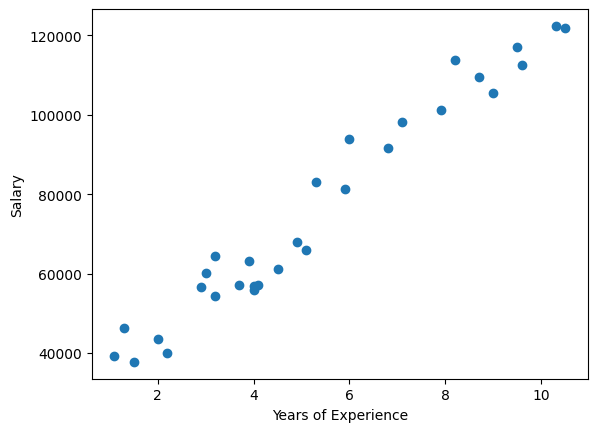

In [65]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

Insight: Scatter plot of dataset suggests a linear distribution with Year of experience being directly proportional to Salary

### Model Training

#### Splitting of Dataset in Training and Test sets

In [66]:
train_set, test_set = train_test_split(df, test_size=0.4, random_state=42)
x_test = test_set['YearsExperience']
y_test = test_set['Salary']

#### Training Model

In [67]:
model = LinearRegression()
model.fit(train_set[['YearsExperience']], train_set['Salary'])

LinearRegression()

### Testing Model

In [68]:
y_pred = model.predict(test_set[['YearsExperience']])

### Checking Model Relevance

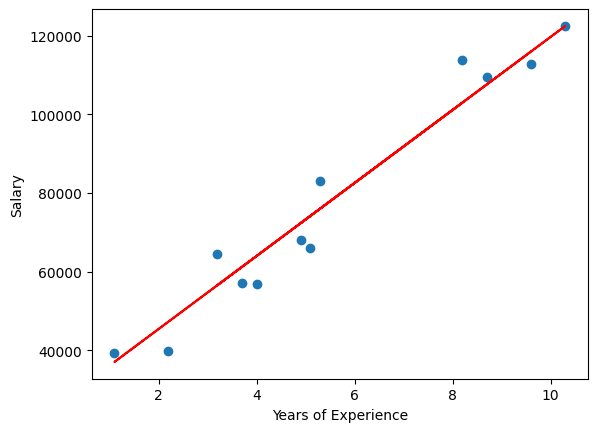

In [69]:
plt.scatter(test_set['YearsExperience'], test_set['Salary'])
plt.plot(test_set['YearsExperience'], y_pred, color='red')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

Insight: Outliers for the Linear Regression model are very close to the line suggesting appropriate model fitness

In [70]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 37867393.38893943
R-squared: 0.9532338376280692


Insight: Since we have R-squared value close to 1 the model is good with variance of salary

### Predicting for User Inputs

In [71]:
input_yearOfExperience = int(input("Enter the number of years of experience: "))
input_yearOfExperience = np.array(input_yearOfExperience)
predicted_salary = model.predict(input_yearOfExperience.reshape(-1, 1))
predicted_salary = np.round(predicted_salary, 2)
print(f"Predicted Salary for {input_yearOfExperience} years of experience: {predicted_salary[0]}")

Enter the number of years of experience: 3
Predicted Salary for 3 years of experience: 54661.24


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
